In [14]:
import itertools
import logging
import os
import re
from typing import Optional

import awkward as ak
import h5py
import hist
import matplotlib.pyplot as plt
import mplhep as hep
import numba as nb
import numpy as np
import vector
from sklearn.metrics import roc_curve, roc_auc_score
vector.register_awkward()

# from utils import get_jets, get_numerical, get_symmetries, match_jet, reset_collision_dp
# from merged import sel_pred_t_by_prob
from utils import get_symmetries

hep.style.use(hep.style.ROOT)
logging.basicConfig(level=logging.INFO)

PLOT_DIR = os.path.join(os.getcwd(), "multi_roc_curves")
os.makedirs(PLOT_DIR, exist_ok=True)

BASE_TPR = np.linspace(0., 1., 1000)
NTOPS = 2
NJETS = 3*NTOPS + 4
NFJETS = NTOPS + 1

FILES = {
    "tt": {"eval": "/storage/af/user/tsievert/topNet/h5s/tt_hadronic_noBQ.h5", "test": "/storage/af/user/tsievert/topNet/h5s/fjTag_testing.h5"},
    "qcd": {"eval": "/storage/af/user/tsievert/topNet/h5s/qcd_4j_Alltesting_noBQeval.h5", "test": "/storage/af/user/tsievert/topNet/h5s/qcd_4j_wTargets_Alltesting.h5"},
    "t": {"eval": "/storage/af/user/tsievert/topNet/h5s/tt_semileptonic_Alltesting_noBQeval.h5", "test": "/storage/af/user/tsievert/topNet/h5s/ttbar_semileptonic/ttbar_semileptonic.h5"}
    # "4t": "",
}


In [ ]:
LOADED_FILES = {label: {filetype: h5py.File(filepath) for filetype, filepath in filepaths.items()} for label, filepaths in FILES.items()}
N_EVTS = {label: len(filepaths['test']['INPUTS']['Jets']['pt']) for label, filepaths in LOADED_FILES.items()}
RECO_CLASSES = sorted(list(LOADED_FILES[next(iter(LOADED_FILES))]["eval"]["SpecialKey.Targets"].keys()))
UNIQUE_RECOS = {unique_reco: [reco for reco in RECO_CLASSES if unique_reco in reco] for unique_reco in sorted(set(item[:re.search('t\d', item).start()] for item in RECO_CLASSES))}
SCORES = [item for item in LOADED_FILES[next(iter(LOADED_FILES))]["eval"]["SpecialKey.Targets"][next(iter(RECO_CLASSES))].keys() if "probability" in item]
ASSIGNMENTS = {unique_reco: [item for item in LOADED_FILES[next(iter(LOADED_FILES))]["eval"]["SpecialKey.Targets"][next(iter(UNIQUE_RECOS[unique_reco]))].keys() if item not in SCORES] for unique_reco in UNIQUE_RECOS.keys()}
SYMMETRIES = dict(zip(UNIQUE_RECOS.keys(), get_symmetries(UNIQUE_RECOS.keys(), ASSIGNMENTS, returnidx=False)))

In [25]:
def n_alpha(string: str):
    return len([c for c in string if c.isalpha()])

def find_correct(unique_reco: str, dataset: dict[str, str]):
    return np.array([
        np.any([
            np.any([
                np.all([
                    (
                        dataset['eval']['SpecialKey.Targets'][eval_reco][assn[0]][:] == dataset['test']['TARGETS'][test_reco][assn[1]][:]
                        if n_alpha(assn[0]) == 1 else
                        dataset['eval']['SpecialKey.Targets'][eval_reco][assn[0]][:] == (dataset['test']['TARGETS'][test_reco][assn[1]][:] + NJETS)
                    ) for assn in symmetry
                ], axis=0)
                for symmetry in SYMMETRIES[unique_reco]
            ], axis=0)
            for test_reco in UNIQUE_RECOS[unique_reco]
        ], axis=0)
        for eval_reco in UNIQUE_RECOS[unique_reco]
    ]).astype("bool")
def find_n_correct(unique_reco: str, dataset: dict[str, str]):
    return np.sum(find_correct(unique_reco, dataset), axis=0)

def find_valid(unique_reco: str, dataset: dict[str, str]):
    return np.array([
        dataset['test']['TARGETS'][test_reco]['MASK'][:]
        for test_reco in UNIQUE_RECOS[unique_reco]
    ]).astype("bool")
def find_n_valid(unique_reco: str, dataset: dict[str, str]):
    return np.sum(find_valid(unique_reco, dataset), axis=0)

def get_preds(unique_reco: str, dataset: dict[str, str], score: str, evt_mask: np.ndarray=None, pred_mask: np.ndarray=None):
    full_preds = np.array([dataset['eval']['SpecialKey.Targets'][reco][score] for reco in UNIQUE_RECOS[unique_reco]])
    if evt_mask is None: evt_mask = np.ones_like(full_preds, dtype=bool)
    else: evt_mask = np.array([evt_mask for _ in UNIQUE_RECOS[unique_reco]])
    if pred_mask is None: pred_mask = np.ones_like(full_preds, dtype=bool)
    full_mask = np.logical_and(evt_mask, pred_mask)
    return full_preds[full_mask]

def get_truths(unique_reco: str, dataset: dict[str, str], evt_mask: np.ndarray=None, pred_mask: np.ndarray=None):
    full_truths = np.array([dataset['eval']['TARGETS'][reco]['MASK'] for reco in UNIQUE_RECOS[unique_reco]])
    if evt_mask is None: evt_mask = np.ones_like(full_truths, dtype=bool)
    else: evt_mask = np.array([evt_mask for _ in UNIQUE_RECOS[unique_reco]])
    if pred_mask is None: pred_mask = np.ones_like(full_truths, dtype=bool)
    full_mask = np.logical_and(evt_mask, pred_mask)
    return full_truths[full_mask]

# def get_sigORbkg_pred_and_truth(reco: str, score: str, datasets: list[tuple[bool, dict[str, str]]]):
#     preds, truths, = [], []
#     for correct_assignment, dataset in datasets:
#         correct_assignment_mask = (find_correct_assignments(reco, dataset) == correct_assignment)
#         all_preds = dataset["eval"]["SpecialKey.Targets"][reco][score][:]
#         all_truths = dataset["test"]["TARGETS"][reco]["MASK"][:]
#         preds.append(all_preds[correct_assignment_mask]); truths.append(all_truths[correct_assignment_mask])
#     return np.concatenate(preds), np.concatenate(truths)

# def get_sigANDbkg_preds_and_truths(reco: str, score: str, roc_curve_datasets: dict[str, list[tuple[bool, dict[str, str]]]]):
#     signal_preds, signal_truths = get_sigORbkg_pred_and_truth(reco, score, roc_curve_datasets['sig'])
#     background_preds, background_truths = get_sigORbkg_pred_and_truth(reco, score, roc_curve_datasets['bkg'])

#     return np.concatenate((signal_preds, background_preds)), np.concatenate((signal_truths, background_truths))

In [ ]:
def interp_roc_curve(truths, preds, **kwargs):
    fpr, tpr, thresholds = roc_curve(truths, preds, **kwargs)
    auc = roc_auc_score(truths, preds, **kwargs)
    interp_fpr = np.interp(BASE_TPR, tpr, fpr)
    interp_thresholds = np.interp(BASE_TPR, tpr, thresholds)
    return interp_fpr, BASE_TPR, interp_thresholds, auc

def plot_roc(fprs: list[np.ndarray], tprs: list[np.ndarray], labels: list[str], title: Optional[str]=None, xlabel: Optional[str]=None, ylabel: Optional[str]=None, save: Optional[str]=None, show: bool=False):
    if xlabel is None: xlabel = 'Bkg Eff.'
    if ylabel is None: ylabel = 'Sig Eff.'

    plt.figure(figsize=(10, 8))
    for fpr, tpr, label in zip(fprs, tprs, labels):
        plt.plot(fpr, tpr, label=label)
    plt.legend()
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xscale('log')
    plt.yscale('log')
    if title is not None: plt.title(title)
    if save is not None: plt.savefig(os.path.join(PLOT_DIR, save))
    if show: plt.show()
    else: plt.close()


In [ ]:
# for roc_curve_label, roc_curve_datasets in ROC_CURVES.items():
#     for reco in RECO_CLASSES:
#         try:
#             fprs, tprs, labels = [], [], []
#             for score in SCORES:
#                 preds, truths = get_sigANDbkg_preds_and_truths(reco, score, roc_curve_datasets)
#                 fpr, tpr, thresholds = roc_curve(truths, preds)
#                 auc = roc_auc_score(truths, preds)
#                 fprinterp = np.interp(BASE_TPR, tpr, fpr)
#                 thresholdsinterp = np.interp(BASE_TPR, tpr, thresholds)
#                 fprs.append(fprinterp); tprs.append(BASE_TPR), labels.append(score.replace('_probability', '')+f' - AUC = {auc:.3f}')
#             plot_roc(fprs, tprs, labels, title=roc_curve_label+' - '+reco, save='_'.join(roc_curve_label.split(' '))+'_'+reco+'.png')
#         except:
#             print(f'Error creating ROC curve for \'{roc_curve_label}\' with class \'{reco}\'')
#             continue
            

/storage/af/user/tsievert/topNet/spatop_venv/lib64/python3.9/site-packages/sklearn/metrics/_ranking.py:1183: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


Error creating ROC curve for 'Correct t vs. QCD' with class 'FBt2'


/storage/af/user/tsievert/topNet/spatop_venv/lib64/python3.9/site-packages/sklearn/metrics/_ranking.py:1183: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


Error creating ROC curve for 'Correct t vs. QCD' with class 'FRt2'


/storage/af/user/tsievert/topNet/spatop_venv/lib64/python3.9/site-packages/sklearn/metrics/_ranking.py:1183: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


...

Error creating ROC curve for 'Correct t vs. Incorrect t' with class 'FBt2'


/storage/af/user/tsievert/topNet/spatop_venv/lib64/python3.9/site-packages/sklearn/metrics/_ranking.py:1183: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


Error creating ROC curve for 'Correct t vs. Incorrect t' with class 'FRt2'


/storage/af/user/tsievert/topNet/spatop_venv/lib64/python3.9/site-packages/sklearn/metrics/_ranking.py:1183: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


Error creating ROC curve for 'Correct t vs. Incorrect t' with class 'SRqqt2'


In [ ]:
ROC_CURVES = {
    # tt performance
    "Correct tt vs. QCD": [{'sig': [{'n_valid': 2, 'n_correct': None, 'dataset': LOADED_FILES["tt"]}], 'bkg': [(False, LOADED_FILES["qcd"])]}],
    # "Correct tt vs. Incorrect tt": {'sig': [(True, LOADED_FILES["tt"])], 'bkg': [(False, LOADED_FILES["tt"])]},
    # # tt vs. t comparison (should be random if theyre equal performance)
    # # "tt vs. t": {'sig': [(True, LOADED_FILES["tt"])], 'bkg': [(True, LOADED_FILES["t"])]},
    # # t performance
    # "Correct t vs. QCD": {'sig': [(True, LOADED_FILES["t"])], 'bkg': [(False, LOADED_FILES["qcd"])]},
    # "Correct t vs. Incorrect t": {'sig': [(True, LOADED_FILES["t"])], 'bkg': [(False, LOADED_FILES["t"])]},
    # # Everything
    # "Correct tt and t vs. QCD and Incorrect tt and t": {'sig': [(True, LOADED_FILES["tt"]), (True, LOADED_FILES["t"])], 'bkg': [(False, LOADED_FILES["qcd"]), (False, LOADED_FILES["tt"]), (False, LOADED_FILES["t"])]},
}

In [ ]:
for roc_curve_label, roc_curve_datasets in ROC_CURVES.items():
    for unique_reco in UNIQUE_RECOS.keys():

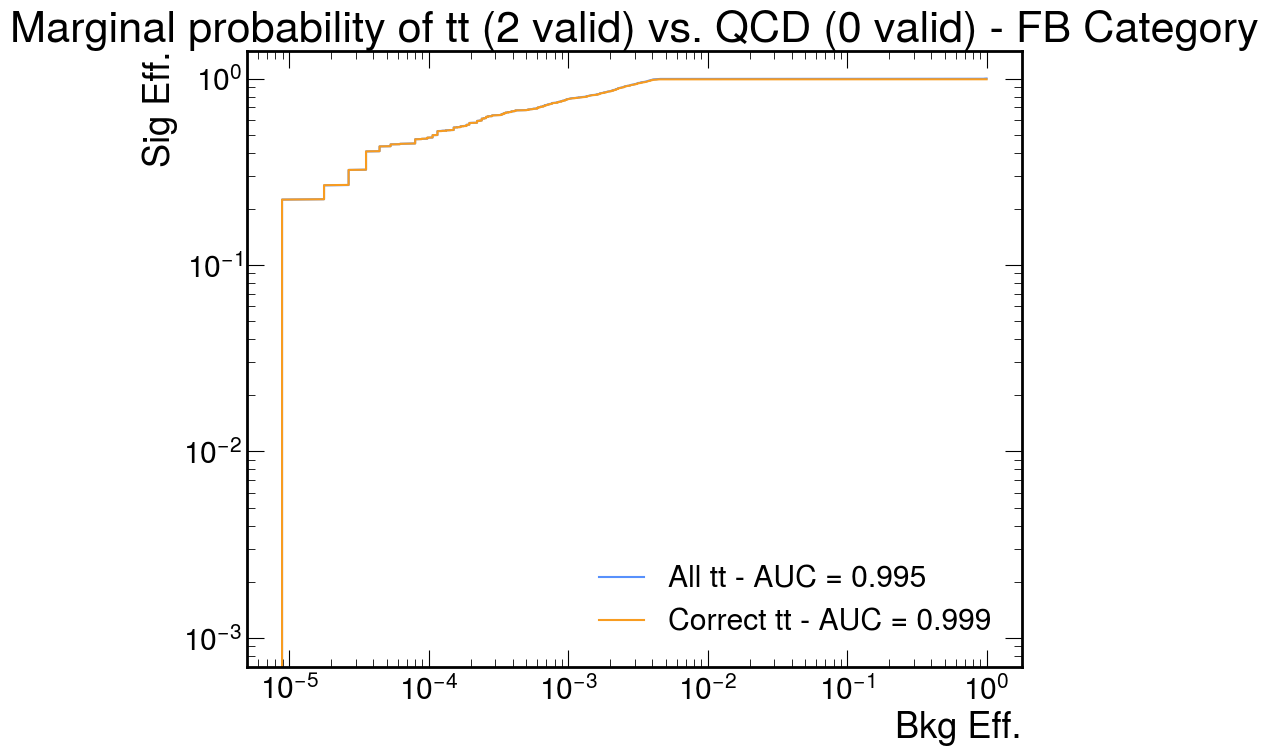

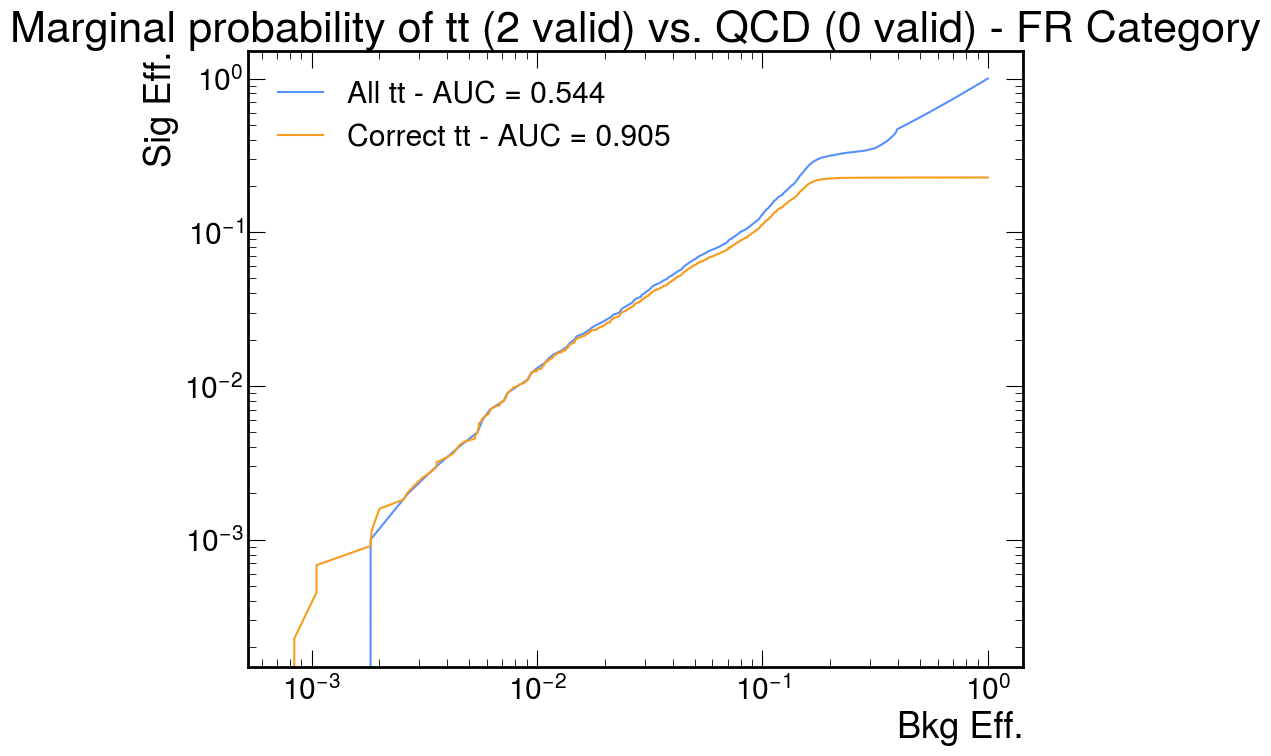

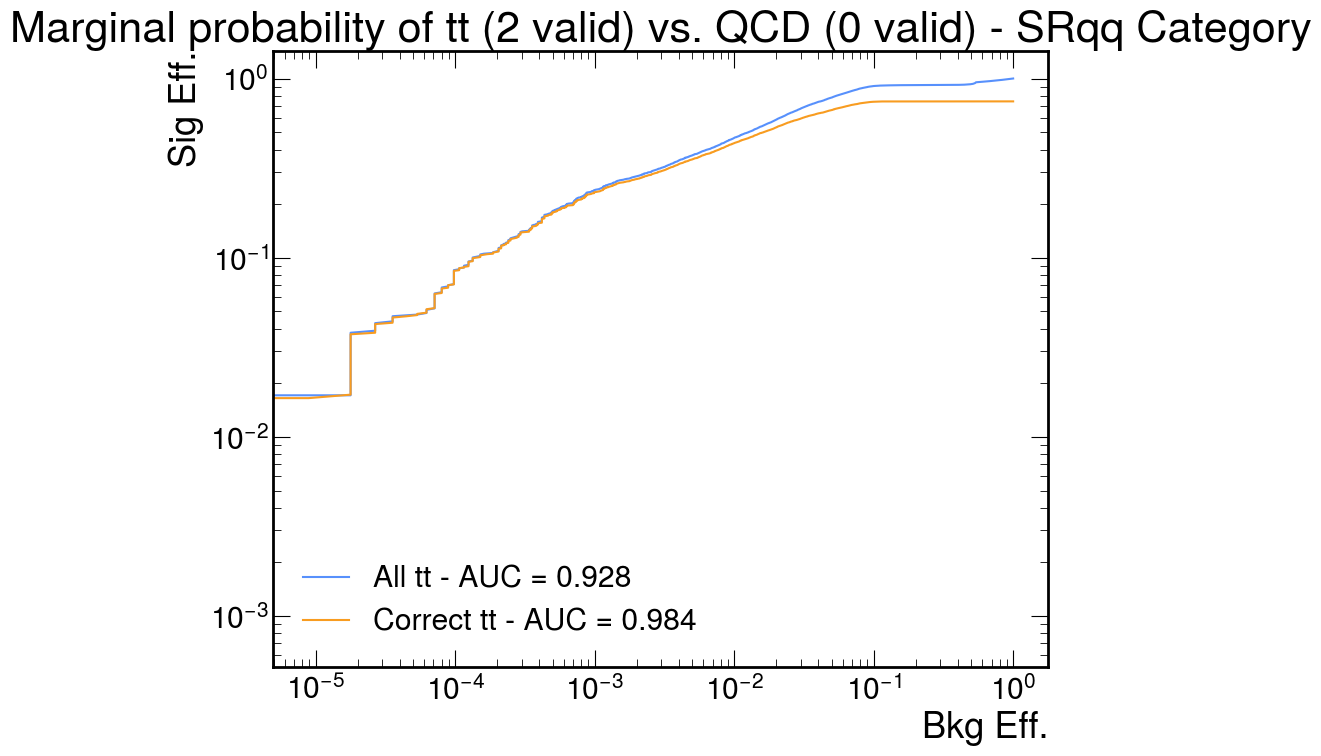

In [32]:
for unique_reco in UNIQUE_RECOS.keys():
    fprs, tprs, labels = [], [], []
    sig_mask = (find_n_valid(unique_reco, LOADED_FILES['tt']) == 2)
    sig_preds = get_preds(unique_reco, LOADED_FILES['tt'], 'marginal_probability', evt_mask=sig_mask)
    sig_label = np.ones_like(sig_preds)

    # bkg_mask = (find_n_valid(unique_reco, LOADED_FILES['qcd']) == 0)
    bkg_preds = get_preds(unique_reco, LOADED_FILES['qcd'], 'marginal_probability')
    bkg_label = np.zeros_like(bkg_preds)
    # bkg_corrpreds = np.concatenate(get_preds(unique_reco, LOADED_FILES['qcd'], 'marginal_probability', evt_mask=bkg_mask, pred_mask=find_correct(unique_reco, LOADED_FILES['qcd'])))
    # bkg_corrlabel = np.ones_like(bkg_corrpreds)

    fpr, tpr, thresholds, auc = interp_roc_curve(np.concatenate([sig_label, bkg_label]), np.concatenate([sig_preds, bkg_preds]))
    fprs.append(fpr), tprs.append(tpr), labels.append(f'All tt - AUC = {auc:.3f}')

    sig_corrpreds = get_preds(unique_reco, LOADED_FILES['tt'], 'marginal_probability', evt_mask=sig_mask, pred_mask=find_correct(unique_reco, LOADED_FILES['tt']))
    sig_corrlabel = np.ones_like(sig_corrpreds)
    rescale_factor = np.sum(find_n_correct(unique_reco, LOADED_FILES['tt'])[sig_mask]) / np.sum(find_n_valid(unique_reco, LOADED_FILES['tt'])[sig_mask])
    fpr1, tpr1, thresholds1, auc1 = interp_roc_curve(np.concatenate([sig_corrlabel, bkg_label]), np.concatenate([sig_corrpreds, bkg_preds]))
    fprs.append(fpr1), tprs.append(tpr1*rescale_factor), labels.append(f'Correct tt - AUC = {auc1:.3f}')

    plot_roc(fprs, tprs, labels, title=f"Marginal probability of tt (2 valid) vs. QCD (0 valid) - {unique_reco} Category", show=True)


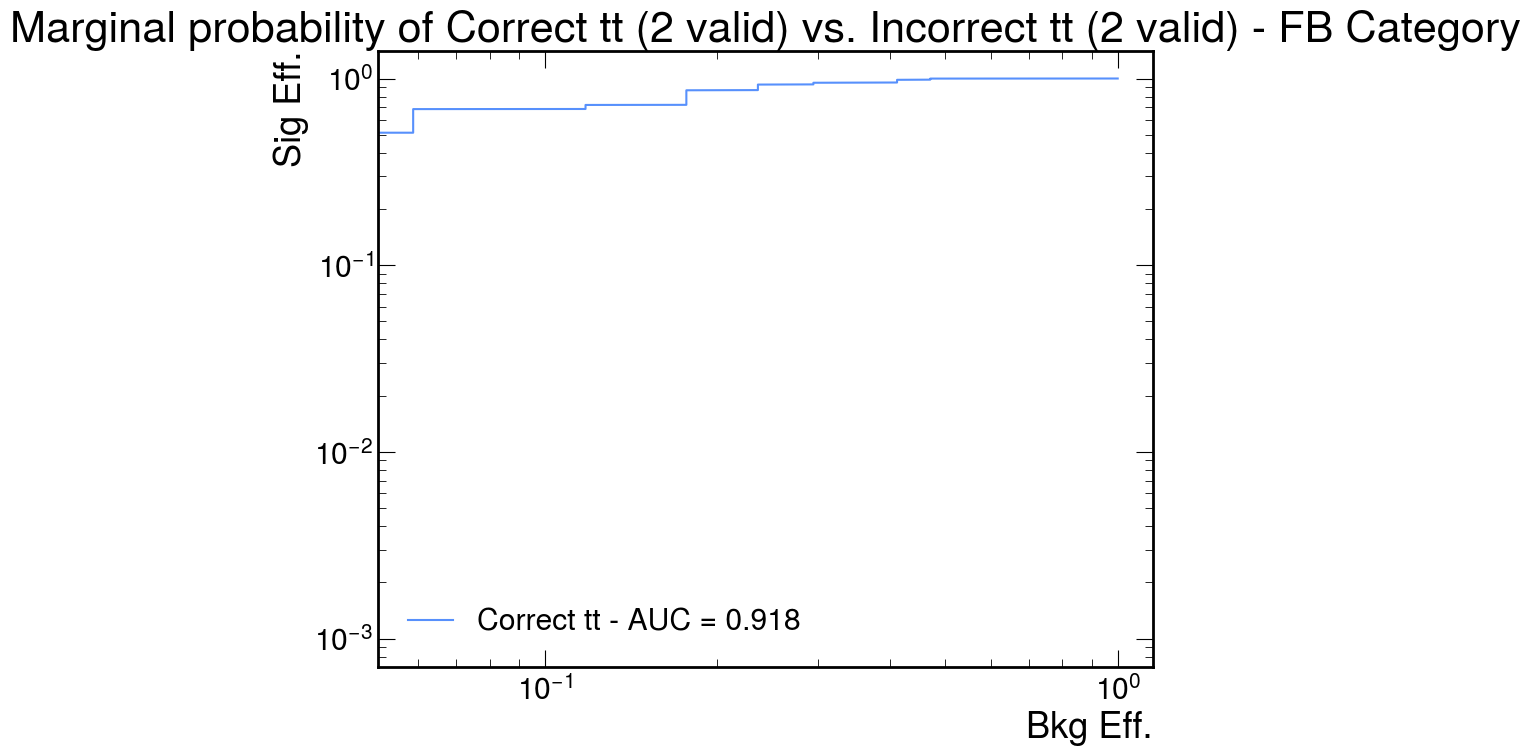

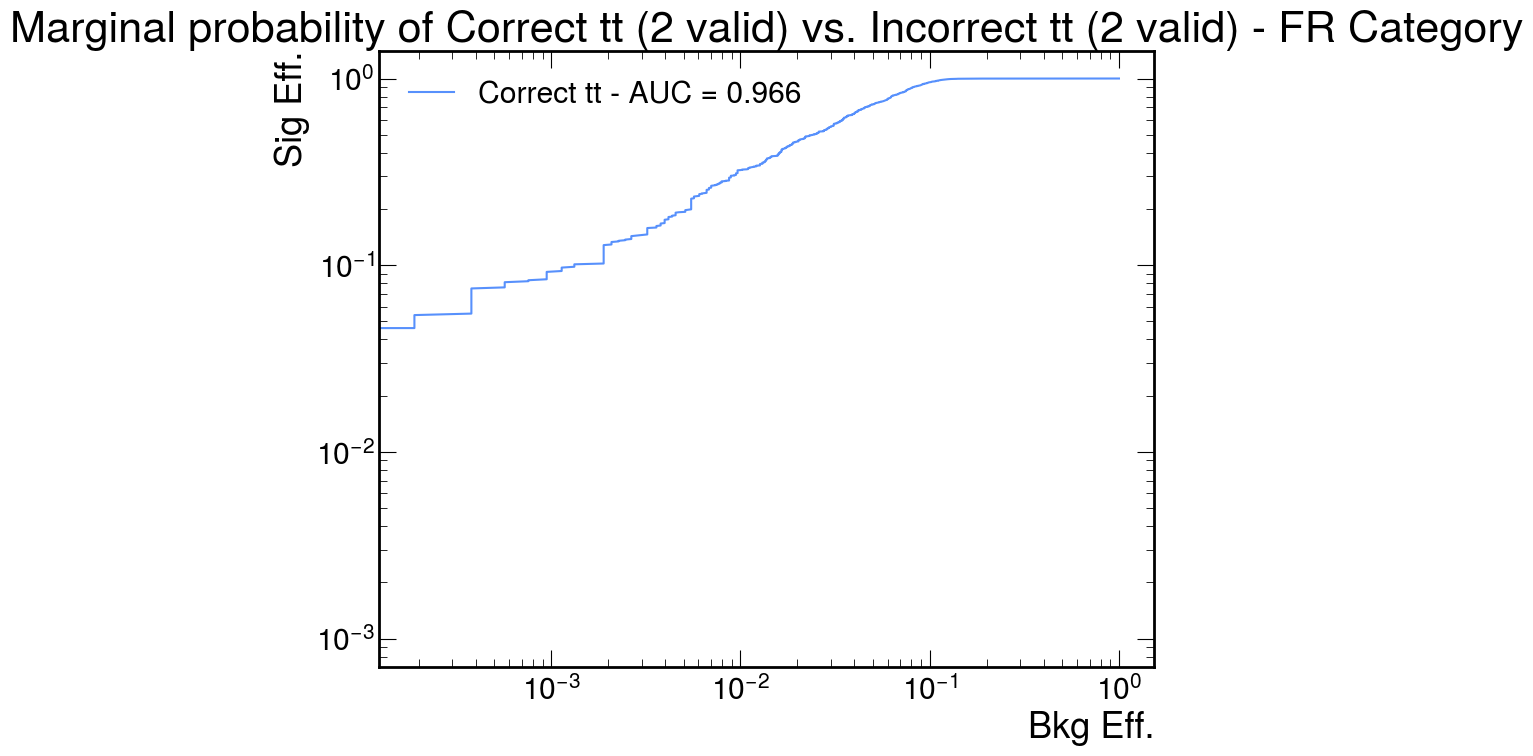

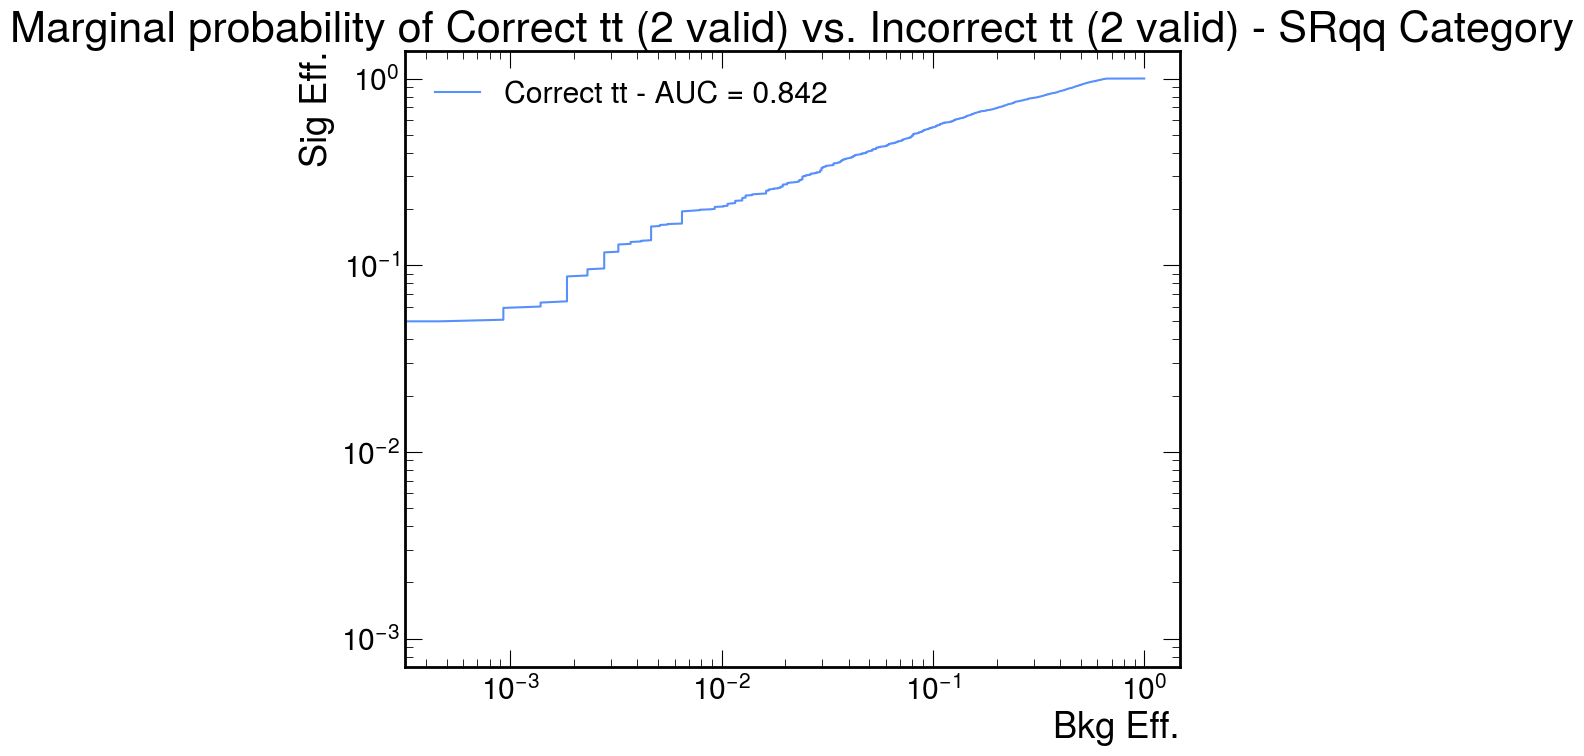

In [33]:
for unique_reco in UNIQUE_RECOS.keys():
    fprs, tprs, labels = [], [], []
    sig_mask = (find_n_valid(unique_reco, LOADED_FILES['tt']) == 2)
    sig_preds = get_preds(unique_reco, LOADED_FILES['tt'], 'marginal_probability', evt_mask=sig_mask, pred_mask=find_correct(unique_reco, LOADED_FILES['tt']))
    sig_label = np.ones_like(sig_preds)

    # bkg_mask = (find_n_valid(unique_reco, LOADED_FILES['qcd']) == 0)
    bkg_preds = get_preds(unique_reco, LOADED_FILES['tt'], 'marginal_probability', evt_mask=sig_mask, pred_mask=~find_correct(unique_reco, LOADED_FILES['tt']))
    bkg_label = np.zeros_like(bkg_preds)
    # bkg_corrpreds = np.concatenate(get_preds(unique_reco, LOADED_FILES['qcd'], 'marginal_probability', evt_mask=bkg_mask, pred_mask=find_correct(unique_reco, LOADED_FILES['qcd'])))
    # bkg_corrlabel = np.ones_like(bkg_corrpreds)

    fpr, tpr, thresholds, auc = interp_roc_curve(np.concatenate([sig_label, bkg_label]), np.concatenate([sig_preds, bkg_preds]))
    fprs.append(fpr), tprs.append(tpr), labels.append(f'Correct tt - AUC = {auc:.3f}')

    # sig_corrpreds = get_preds(unique_reco, LOADED_FILES['tt'], 'marginal_probability', evt_mask=sig_mask, pred_mask=find_correct(unique_reco, LOADED_FILES['tt']))
    # sig_corrlabel = np.ones_like(sig_corrpreds)
    # rescale_factor = np.sum(find_n_correct(unique_reco, LOADED_FILES['tt'])[sig_mask]) / np.sum(find_n_valid(unique_reco, LOADED_FILES['tt'])[sig_mask])
    # fpr1, tpr1, thresholds1, auc1 = interp_roc_curve(np.concatenate([sig_corrlabel, bkg_label]), np.concatenate([sig_corrpreds, bkg_preds]))
    # fprs.append(fpr1), tprs.append(tpr1*rescale_factor), labels.append(f'Correct tt - AUC = {auc1:.3f}')

    plot_roc(fprs, tprs, labels, title=f"Marginal probability of Correct tt (2 valid) vs. Incorrect tt (2 valid) - {unique_reco} Category", show=True)

In [30]:
for files in LOADED_FILES.values(): 
    for file in files.values(): file.close()